In [1]:
import pandas as pd

In [2]:
data_df = pd.read_csv("../data/ethiopia/output/ethiopia_crop_and_conflict.csv")
data_df

,Unnamed: 0,woreda,area_ha_2016,area_ha_2017,area_ha_2018,area_ha_2019,area_ha_2020,area_ha_2021,area_ha_2022,area_ha_2023,...,percent_change_21_22,change_22_23,percent_change_22_23,change_23_24,percent_change_23_24,estimated_deaths_2020,estimated_deaths_2021,estimated_deaths_2022,estimated_deaths_2023,estimated_deaths_2024
0,0,AbAla,3893,5769,3634,2722,4800,4071,2869,2449,...,-29,-419,-14,538,21,0,286,24,0,0
1,1,Ababo,17193,20064,19454,21440,19125,22330,20055,17820,...,-10,-2235,-11,-1772,-9,0,0,0,8,2
2,2,AbayChomen,22291,23768,23232,25193,24085,24299,22500,21906,...,-7,-593,-2,-1297,-5,0,0,0,20,17
3,3,Abaya,17704,16055,14254,16927,9228,12158,17780,18176,...,46,395,2,-9391,-51,0,0,1,0,1
4,4,AbeDongoro,14038,20677,16295,22732,14594,27842,19861,16769,...,-28,-3091,-15,-1641,-9,0,0,0,12,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,370,YilmanaDensa,85091,83157,88745,86608,85446,85729,87165,87160,...,1,-4,0,-3217,-3,0,0,0,12,75
352,371,Yubdo,2984,3339,5525,4946,4260,4922,4365,3858,...,-11,-506,-11,-399,-10,0,0,0,0,5
353,372,Zala,9324,20169,16871,26417,17429,21039,23647,29387,...,12,5740,24,-6996,-23,25,0,0,0,0
354,373,Ziquala,7625,9256,8795,11125,9878,12848,8900,15558,...,-30,6657,74,-7189,-46,0,0,1,0,0


In [3]:
data_df = data_df.drop(columns=['Unnamed: 0'])
data_df

,woreda,area_ha_2016,area_ha_2017,area_ha_2018,area_ha_2019,area_ha_2020,area_ha_2021,area_ha_2022,area_ha_2023,area_ha_2024,...,percent_change_21_22,change_22_23,percent_change_22_23,change_23_24,percent_change_23_24,estimated_deaths_2020,estimated_deaths_2021,estimated_deaths_2022,estimated_deaths_2023,estimated_deaths_2024
0,AbAla,3893,5769,3634,2722,4800,4071,2869,2449,2988,...,-29,-419,-14,538,21,0,286,24,0,0
1,Ababo,17193,20064,19454,21440,19125,22330,20055,17820,16047,...,-10,-2235,-11,-1772,-9,0,0,0,8,2
2,AbayChomen,22291,23768,23232,25193,24085,24299,22500,21906,20609,...,-7,-593,-2,-1297,-5,0,0,0,20,17
3,Abaya,17704,16055,14254,16927,9228,12158,17780,18176,8785,...,46,395,2,-9391,-51,0,0,1,0,1
4,AbeDongoro,14038,20677,16295,22732,14594,27842,19861,16769,15127,...,-28,-3091,-15,-1641,-9,0,0,0,12,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,YilmanaDensa,85091,83157,88745,86608,85446,85729,87165,87160,83943,...,1,-4,0,-3217,-3,0,0,0,12,75
352,Yubdo,2984,3339,5525,4946,4260,4922,4365,3858,3458,...,-11,-506,-11,-399,-10,0,0,0,0,5
353,Zala,9324,20169,16871,26417,17429,21039,23647,29387,22390,...,12,5740,24,-6996,-23,25,0,0,0,0
354,Ziquala,7625,9256,8795,11125,9878,12848,8900,15558,8368,...,-30,6657,74,-7189,-46,0,0,1,0,0


In [5]:
# remove outlier woreda
data_df = data_df[data_df["woreda"] != "Tsegede"]

In [6]:
# Create analysis_df with one row per woreda per year
analysis_data = []

for _, row in data_df.iterrows():
    woreda = row['woreda']
    
    # Year 2021: percent_change_20_21, estimated_deaths_2020
    analysis_data.append({
        'woreda': woreda,
        'year': 2021,
        'crop_change': row['change_20_21'],
        'estimated_deaths': row['estimated_deaths_2020']
    })
    
    # Year 2022: percent_change_21_22, estimated_deaths_2021
    analysis_data.append({
        'woreda': woreda,
        'year': 2022,
        'crop_change': row['change_21_22'],
        'estimated_deaths': row['estimated_deaths_2021']
    })
    
    # Year 2023: percent_change_22_23, estimated_deaths_2022
    analysis_data.append({
        'woreda': woreda,
        'year': 2023,
        'crop_change': row['change_22_23'],
        'estimated_deaths': row['estimated_deaths_2022']
    })
    
    # Year 2024: percent_change_23_24, estimated_deaths_2023
    analysis_data.append({
        'woreda': woreda,
        'year': 2024,
        'crop_change': row['change_23_24'],
        'estimated_deaths': row['estimated_deaths_2023']
    })

analysis_df = pd.DataFrame(analysis_data)
analysis_df

,woreda,year,crop_change,estimated_deaths
0,AbAla,2021,-729,0
1,AbAla,2022,-1201,286
2,AbAla,2023,-419,24
3,AbAla,2024,538,0
4,Ababo,2021,3204,0
...,...,...,...,...
1415,Ziquala,2024,-7189,0
1416,ZiwayDugda,2021,4986,59
1417,ZiwayDugda,2022,-1490,4
1418,ZiwayDugda,2023,-2046,9


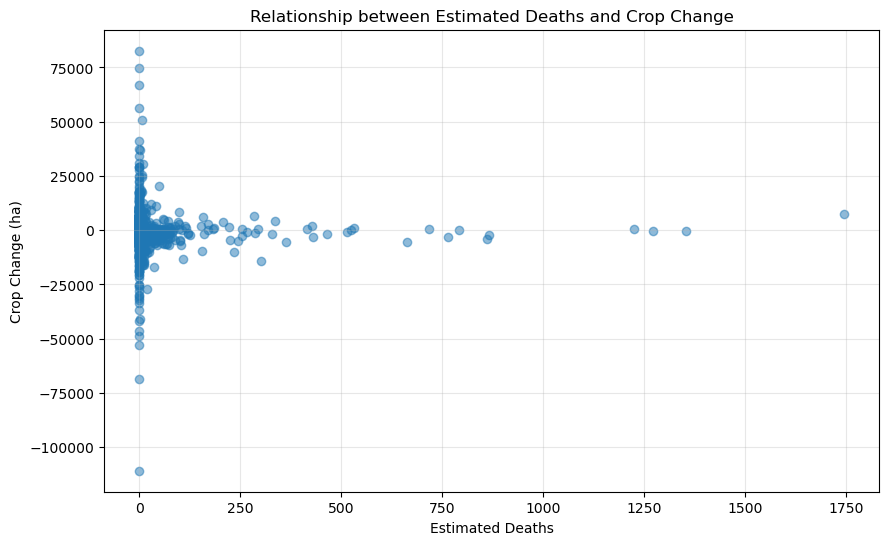

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(analysis_df['estimated_deaths'], analysis_df['crop_change'], alpha=0.5)
plt.xlabel('Estimated Deaths')
plt.ylabel('Crop Change (ha)')
plt.title('Relationship between Estimated Deaths and Crop Change')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
analysis_high_df = analysis_df[analysis_df["estimated_deaths"] > 100]

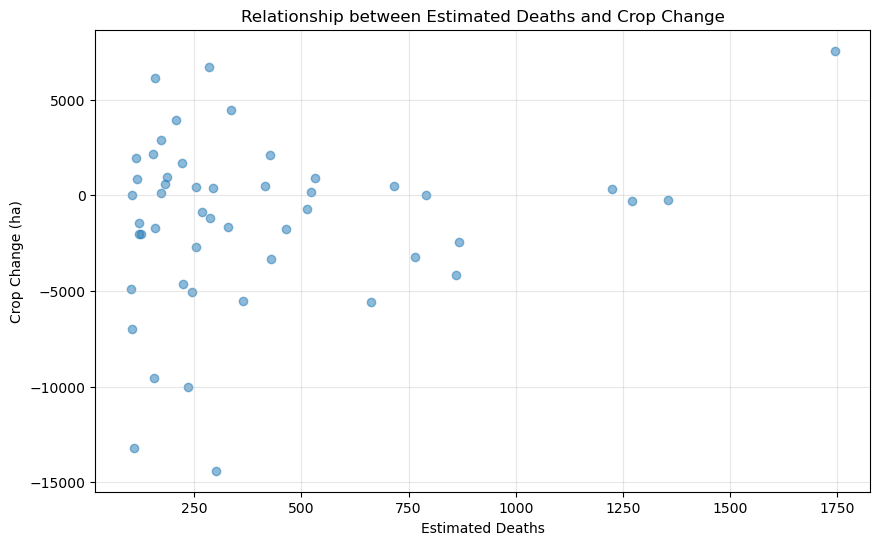

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(analysis_high_df['estimated_deaths'], analysis_high_df['crop_change'], alpha=0.5)
plt.xlabel('Estimated Deaths')
plt.ylabel('Crop Change (ha)')
plt.title('Relationship between Estimated Deaths and Crop Change')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
analysis_df.to_csv("../data/ethiopia/output/ethiopia_annual_conflict_deaths_and_crop_change.csv", index=False)